# Visualizing Cell and Molecular Cascades

This tutorial demonstrates how to represent a ReCoN molecular cascade as a **biological cell diagram**. Unlike a Sankey diagram, the cascade plot places ligands in the extracellular space and regulatory molecules inside their source or receiving cells.

You will learn how to:

1. Build and explore the same multicellular network used in the Sankey tutorial
2. Draw intracellular regulation in a selected cell type
3. Extend the view to extracellular ligands
4. Display the complete cascade, including regulation in source cells
5. Inspect the edges selected for each plot
6. Compare ReCoN results from two conditions with a contrast cascade

**Use case**: Given a list of seed genes in one cell type, visualize the receptors, transcription factors, ligands, and neighboring cell types connected to these genes by ReCoN.

> This tutorial follows the [`2.2.Heart_Failure_cascade_plots.ipynb`](https://github.com/cantinilab/recon_reproducibility/blob/main/showcases_paper/Heart_Infarction_Fibrosis/2.2.Heart_Failure_cascade_plots.ipynb) workflow in the [`recon_reproducibility`](https://github.com/cantinilab/recon_reproducibility) repository.

## Setup

Tutorials 3 and 7 share the same input data and network construction. Download the required files if they are not already available:

In [81]:
from recon.data import fetch_tutorial_data

for filename in [
    "perturbation_tuto/rna.h5ad",
    "perturbation_tuto/grn.csv",
]:
    fetch_tutorial_data(filename, data_dir="./data")

File already exists: ./data/perturbation_tuto/rna.h5ad
File already exists: ./data/perturbation_tuto/grn.csv


In [82]:
import numpy as np
import pandas as pd
import scanpy as sc
import liana as li

import recon
import recon.data
import recon.explore
from recon.plot import cascade_plot, contrast_cascade_plot

## 1. Create the multicellular network

```{note}
**In short**

Build the GRN, receptor links, and cell-cell communication network used by ReCoN.
```

A cascade plot does not infer a new network. It extracts connected paths from a `Multicell` model and its RWR results. We therefore reproduce the setup from the Sankey tutorial: a GRN for intracellular regulation, a LIANA network for cell-cell communication, and receptor-to-gene prior knowledge.

In [83]:
rna = sc.read_h5ad("./data/perturbation_tuto/rna.h5ad")

grn = pd.read_csv("./data/perturbation_tuto/grn.csv")
grn = grn.sort_values("weight", ascending=False).head(500_000)
grn["source"] = grn["source"].str.capitalize() + "_TF"
grn["target"] = grn["target"].str.capitalize()

li.method.cellphonedb(
    rna, resource_name="mouseconsensus", expr_prop=0.0, use_raw=False,
    groupby="celltype", verbose=True, key_added="cpdb_res",
)
ccc = rna.uns["cpdb_res"][[
    "ligand", "receptor", "lr_means", "source", "target"
]].rename(columns={
    "ligand": "source", "receptor": "target", "lr_means": "weight",
    "source": "celltype_source", "target": "celltype_target",
})
ccc = ccc[ccc["weight"] != 0].copy()

receptor_genes = recon.data.load_data.load_receptor_genes(
    "mouse_receptor_gene_from_NichenetPKN"
)
network_genes = set(grn["source"]) | set(grn["target"])
receptor_genes = receptor_genes[receptor_genes["target"].isin(network_genes)]

Using resource `mouseconsensus`.
Using `.X`!
/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/recon/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
15364 features of mat are empty, they will be removed.
Make sure that normalized counts are passed!
/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/recon/lib/python3.10/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/recon/lib/python3.10/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.36 of entities in the resource are missing 

Generating ligand-receptor stats for 1296 samples and 937 features


100%|██████████| 1000/1000 [00:01<00:00, 606.44it/s]


### Define the seed genes and cell type

The seed genes are the genes for which we want to find upstream regulators. Adding `::Macrophage` tells ReCoN to study these genes specifically in macrophages.

In [84]:
seed_genes = ["Nfkb1", "Tnf", "Il6", "Ccl2", "Cxcl10"]
focal_celltype = "Macrophage"
seeds = {f"{gene}::{focal_celltype}": 1.0 for gene in seed_genes}

celltypes = ["B_cell", "pDC", "Macrophage", "NK_cell", "T_cell_CD4", "T_cell_CD8"]
ligand_source_cells = [ct for ct in celltypes if ct != focal_celltype]

In [85]:
multicell = recon.explore.Multicell(
    celltypes={ct: recon.explore.Celltype(
        celltype_name=ct, grn_graph=grn, receptor_grn_bipartite=receptor_genes,
        receptor_graph_directed=False, receptor_graph_weighted=False,
        grn_graph_directed=False, grn_graph_weighted=True,
        receptor_grn_bipartite_graph_directed=False,
        receptor_grn_bipartite_graph_weighted=True, seeds=[],
    ) for ct in celltypes},
    cell_communication_graph=ccc[
        ccc["celltype_source"].isin(celltypes) & ccc["celltype_target"].isin(celltypes)
    ],
    cell_communication_graph_directed=False,
    cell_communication_graph_weighted=True,
    bipartite_grn_cell_communication_directed=False,
    bipartite_grn_cell_communication_weighted=False,
    bipartite_cell_communication_receptor_directed=False,
    bipartite_cell_communication_receptor_weighted=False,
    seeds=seeds,
)
multicell.lamb = recon.explore.set_lambda(
    multicell, direction="upstream", strategy="intercell"
)
results = multicell.explore(restart_proba=0.6)

/pasteur/helix/projects/ml4ig_hot/Users/rtrimbou/ReCoN/src/recon/explore/recon.py:132: UserWarning: 
                No receptor_graph provided,
                an empty receptor graph will be created.
                
/pasteur/helix/projects/ml4ig_hot/Users/rtrimbou/ReCoN/src/recon/explore/recon.py:474: UserWarning: The celltypes dictionary was converted to a list of Celltype objects.
The keys of the dictionary will be the celltype names.


Seeds are provided as a dictionary with weights per seed.
Creating a multixrank object with seeds as a dictionary.
cell_communication
receptor
gene
receptor
gene
receptor
gene
receptor
gene
receptor
gene
receptor
gene
Identifying produced ligands in response to the perturbation.


## 2. Choose what the cascade should display

```{note}
**In short**

Choose which network layers to display; fewer layers usually produce a clearer figure.
```

The full biological cascade contains six successive roles:

```text
source-cell receptor → source-cell TF → ligand
                   → selected-cell receptor → selected-cell TF → selected-cell gene
```

`start_layer` and `stop_layer` select the first and last layers shown in the cascade. This is useful because the complete network can be too dense when only one part of the signaling path is needed.

In [86]:
common_plot_kwargs = dict(
    cell_type=focal_celltype,
    seeds=seed_genes,
    ligand_cells=ligand_source_cells,
    top_ligand_n=8,
    top_receptor_n=8,
    top_tf_n=10,
    before_top_n=5,
    per_celltype=False,
    show_labels=True,
    label_fontsize=10,
    show_seeds=True,
    max_seed_nodes=5,
)

### Intracellular regulation

First, keep only receptors, TFs, and seed genes in macrophages. This answers: **which receptors and TFs are connected to the selected genes inside macrophages?**

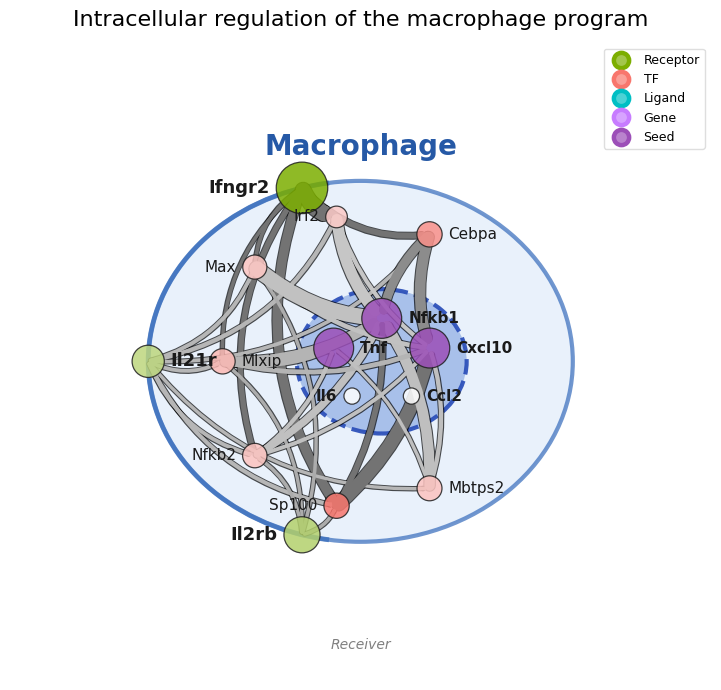

{'upstream_r_tf': 0,
 'upstream_tf_lig': 0,
 'lig_rec': 0,
 'rec_tf': 17,
 'tf_gene': 17}

In [87]:
fig, ax, intracellular_edges = cascade_plot(
    multicell, results,
    flow="upstream",
    start_layer="receptors",
    stop_layer="genes",
    title="Intracellular regulation of the macrophage program",
    return_edges=True,
    **common_plot_kwargs,
)
{k: len(v) for k, v in intracellular_edges.items()}

In [88]:
from collections import Counter

labels = Counter(text.get_text() for text in ax.texts)
{name: count for name, count in labels.items() if count > 1}

{}

### Include extracellular ligands

Starting at ligands adds signals produced by other cell types. This answers: **which ligands may regulate the selected macrophage genes, and through which receptors and TFs?**

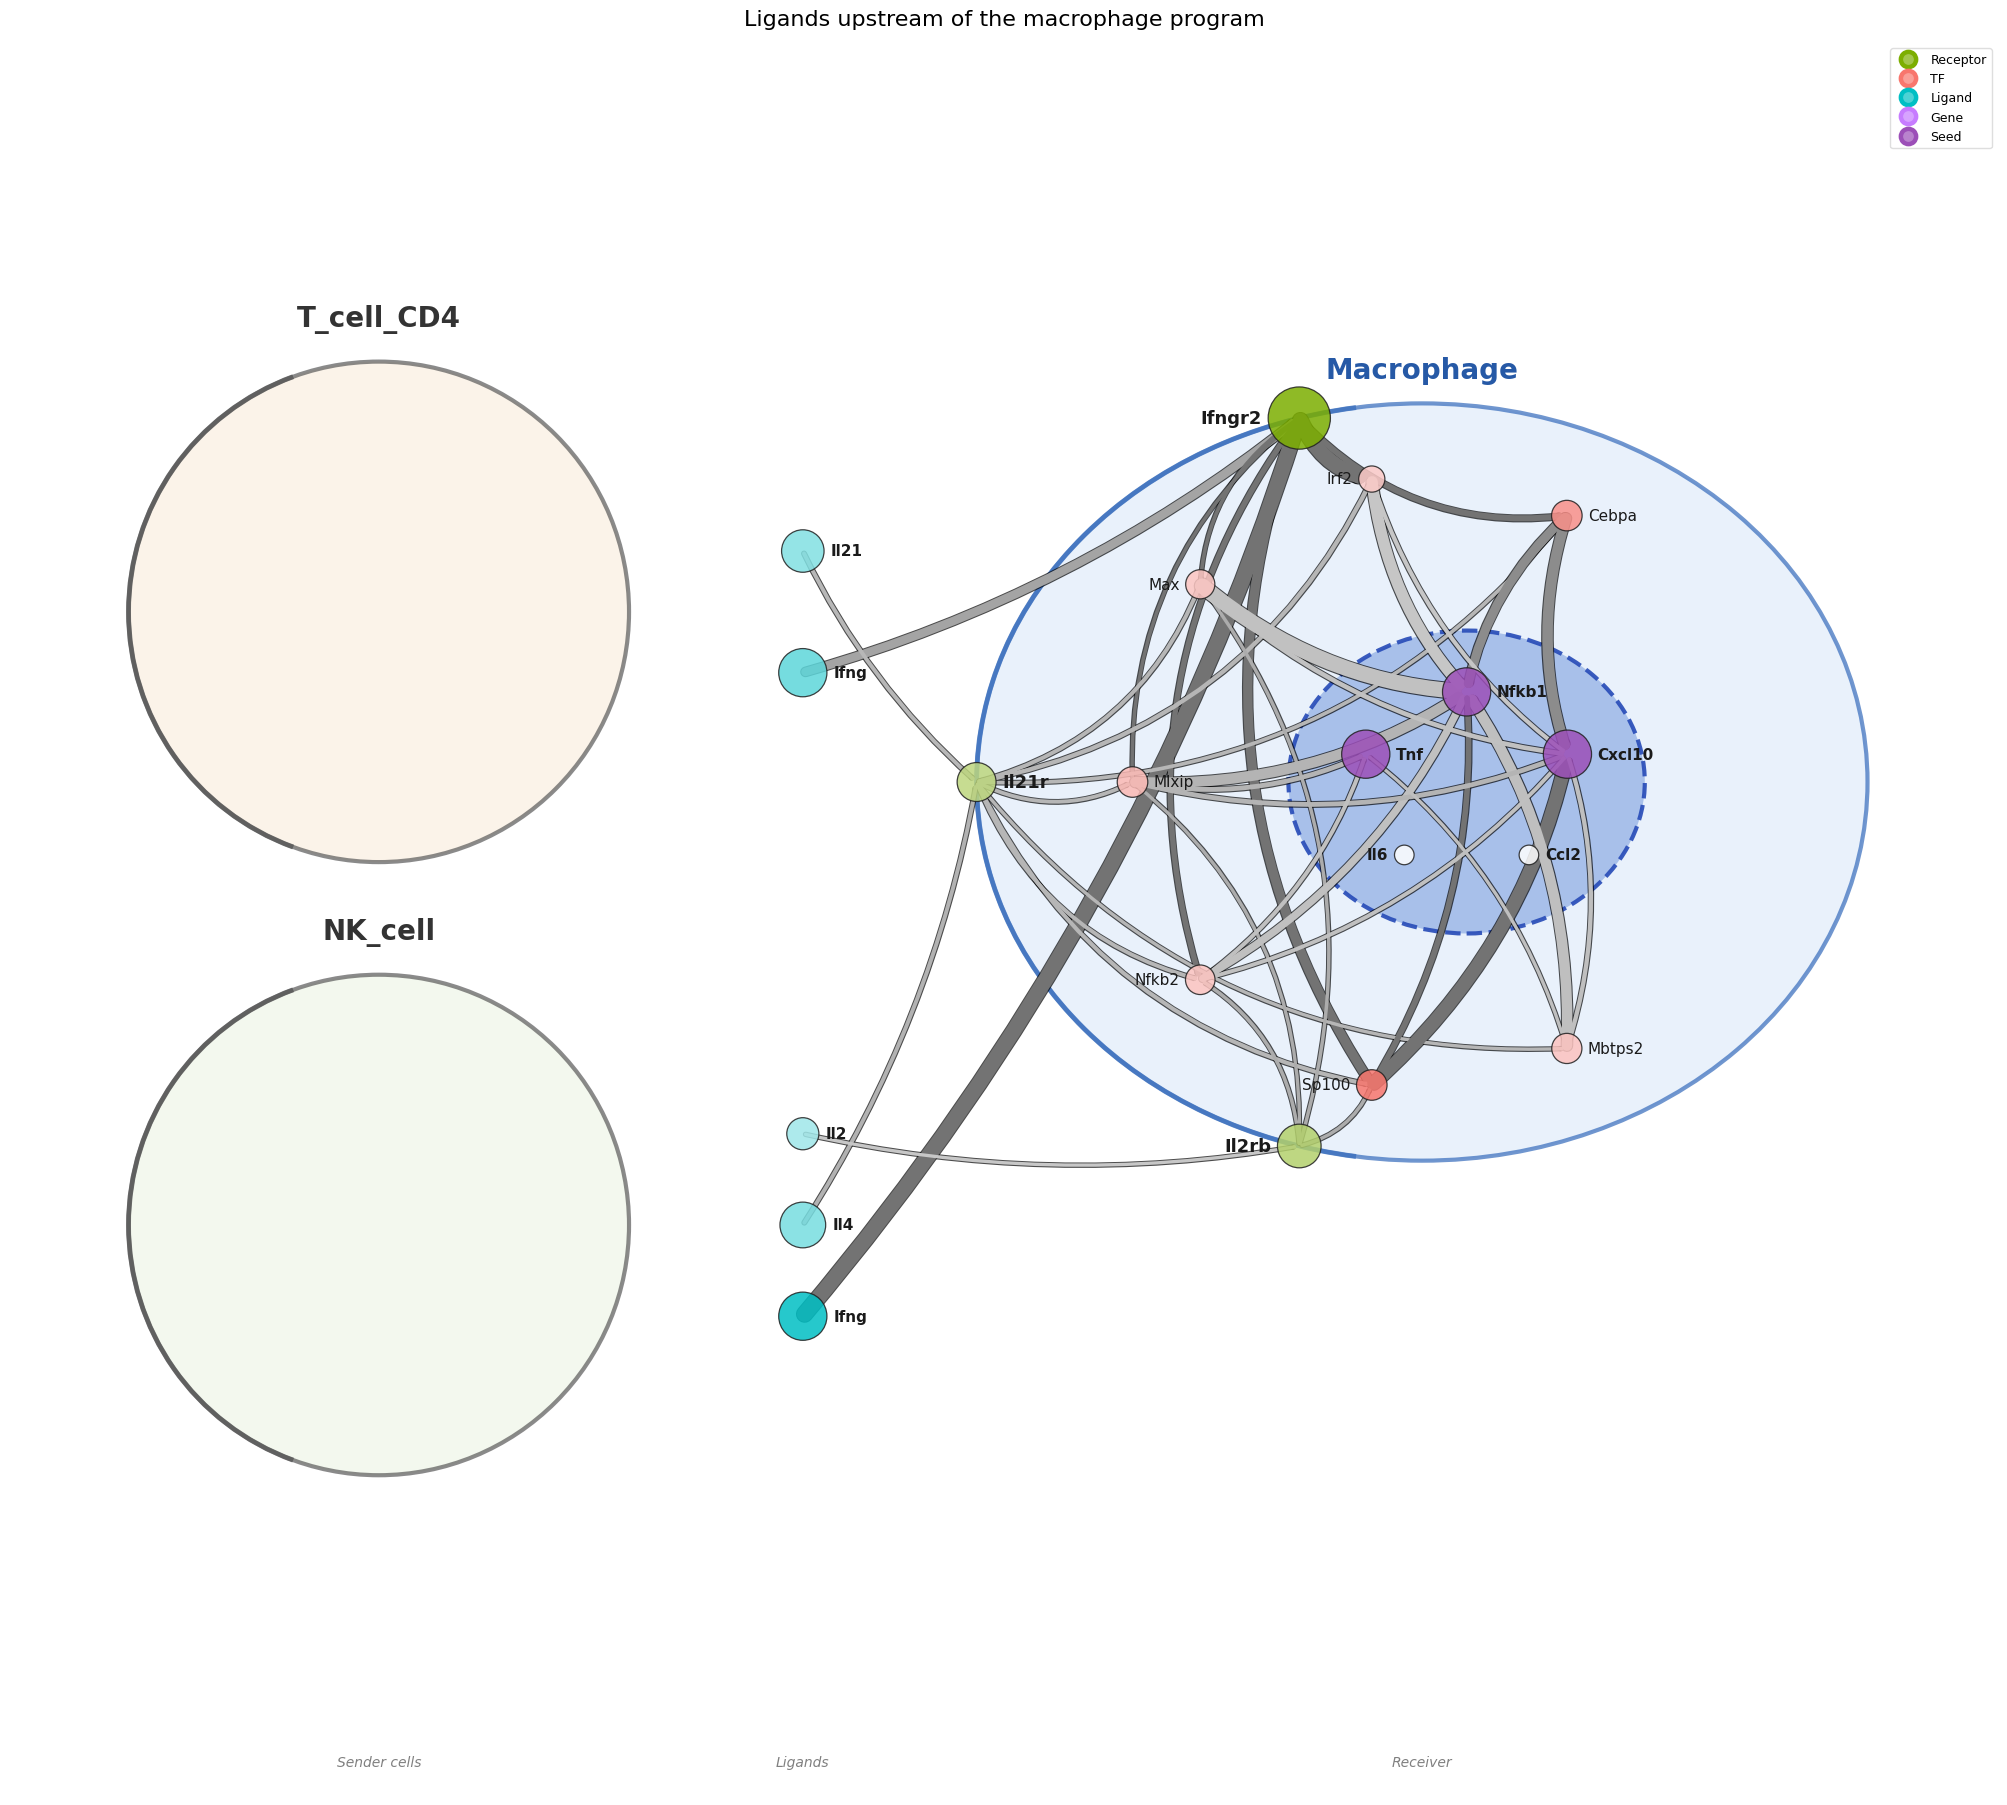

{'upstream_r_tf': 0,
 'upstream_tf_lig': 0,
 'lig_rec': 5,
 'rec_tf': 17,
 'tf_gene': 17}

In [89]:
fig, ax, ligand_edges = cascade_plot(
    multicell, results,
    flow="upstream",
    start_layer="ligands",
    stop_layer="genes",
    title="Ligands upstream of the macrophage program",
    return_edges=True,
    **common_plot_kwargs,
)
{k: len(v) for k, v in ligand_edges.items()}

### Complete source-cell cascade

Leaving `start_layer` and `stop_layer` unset displays the complete cascade. It adds receptors and TFs in the cells producing the ligands. This answers: **which regulators in neighboring cells may control production of these ligands?**

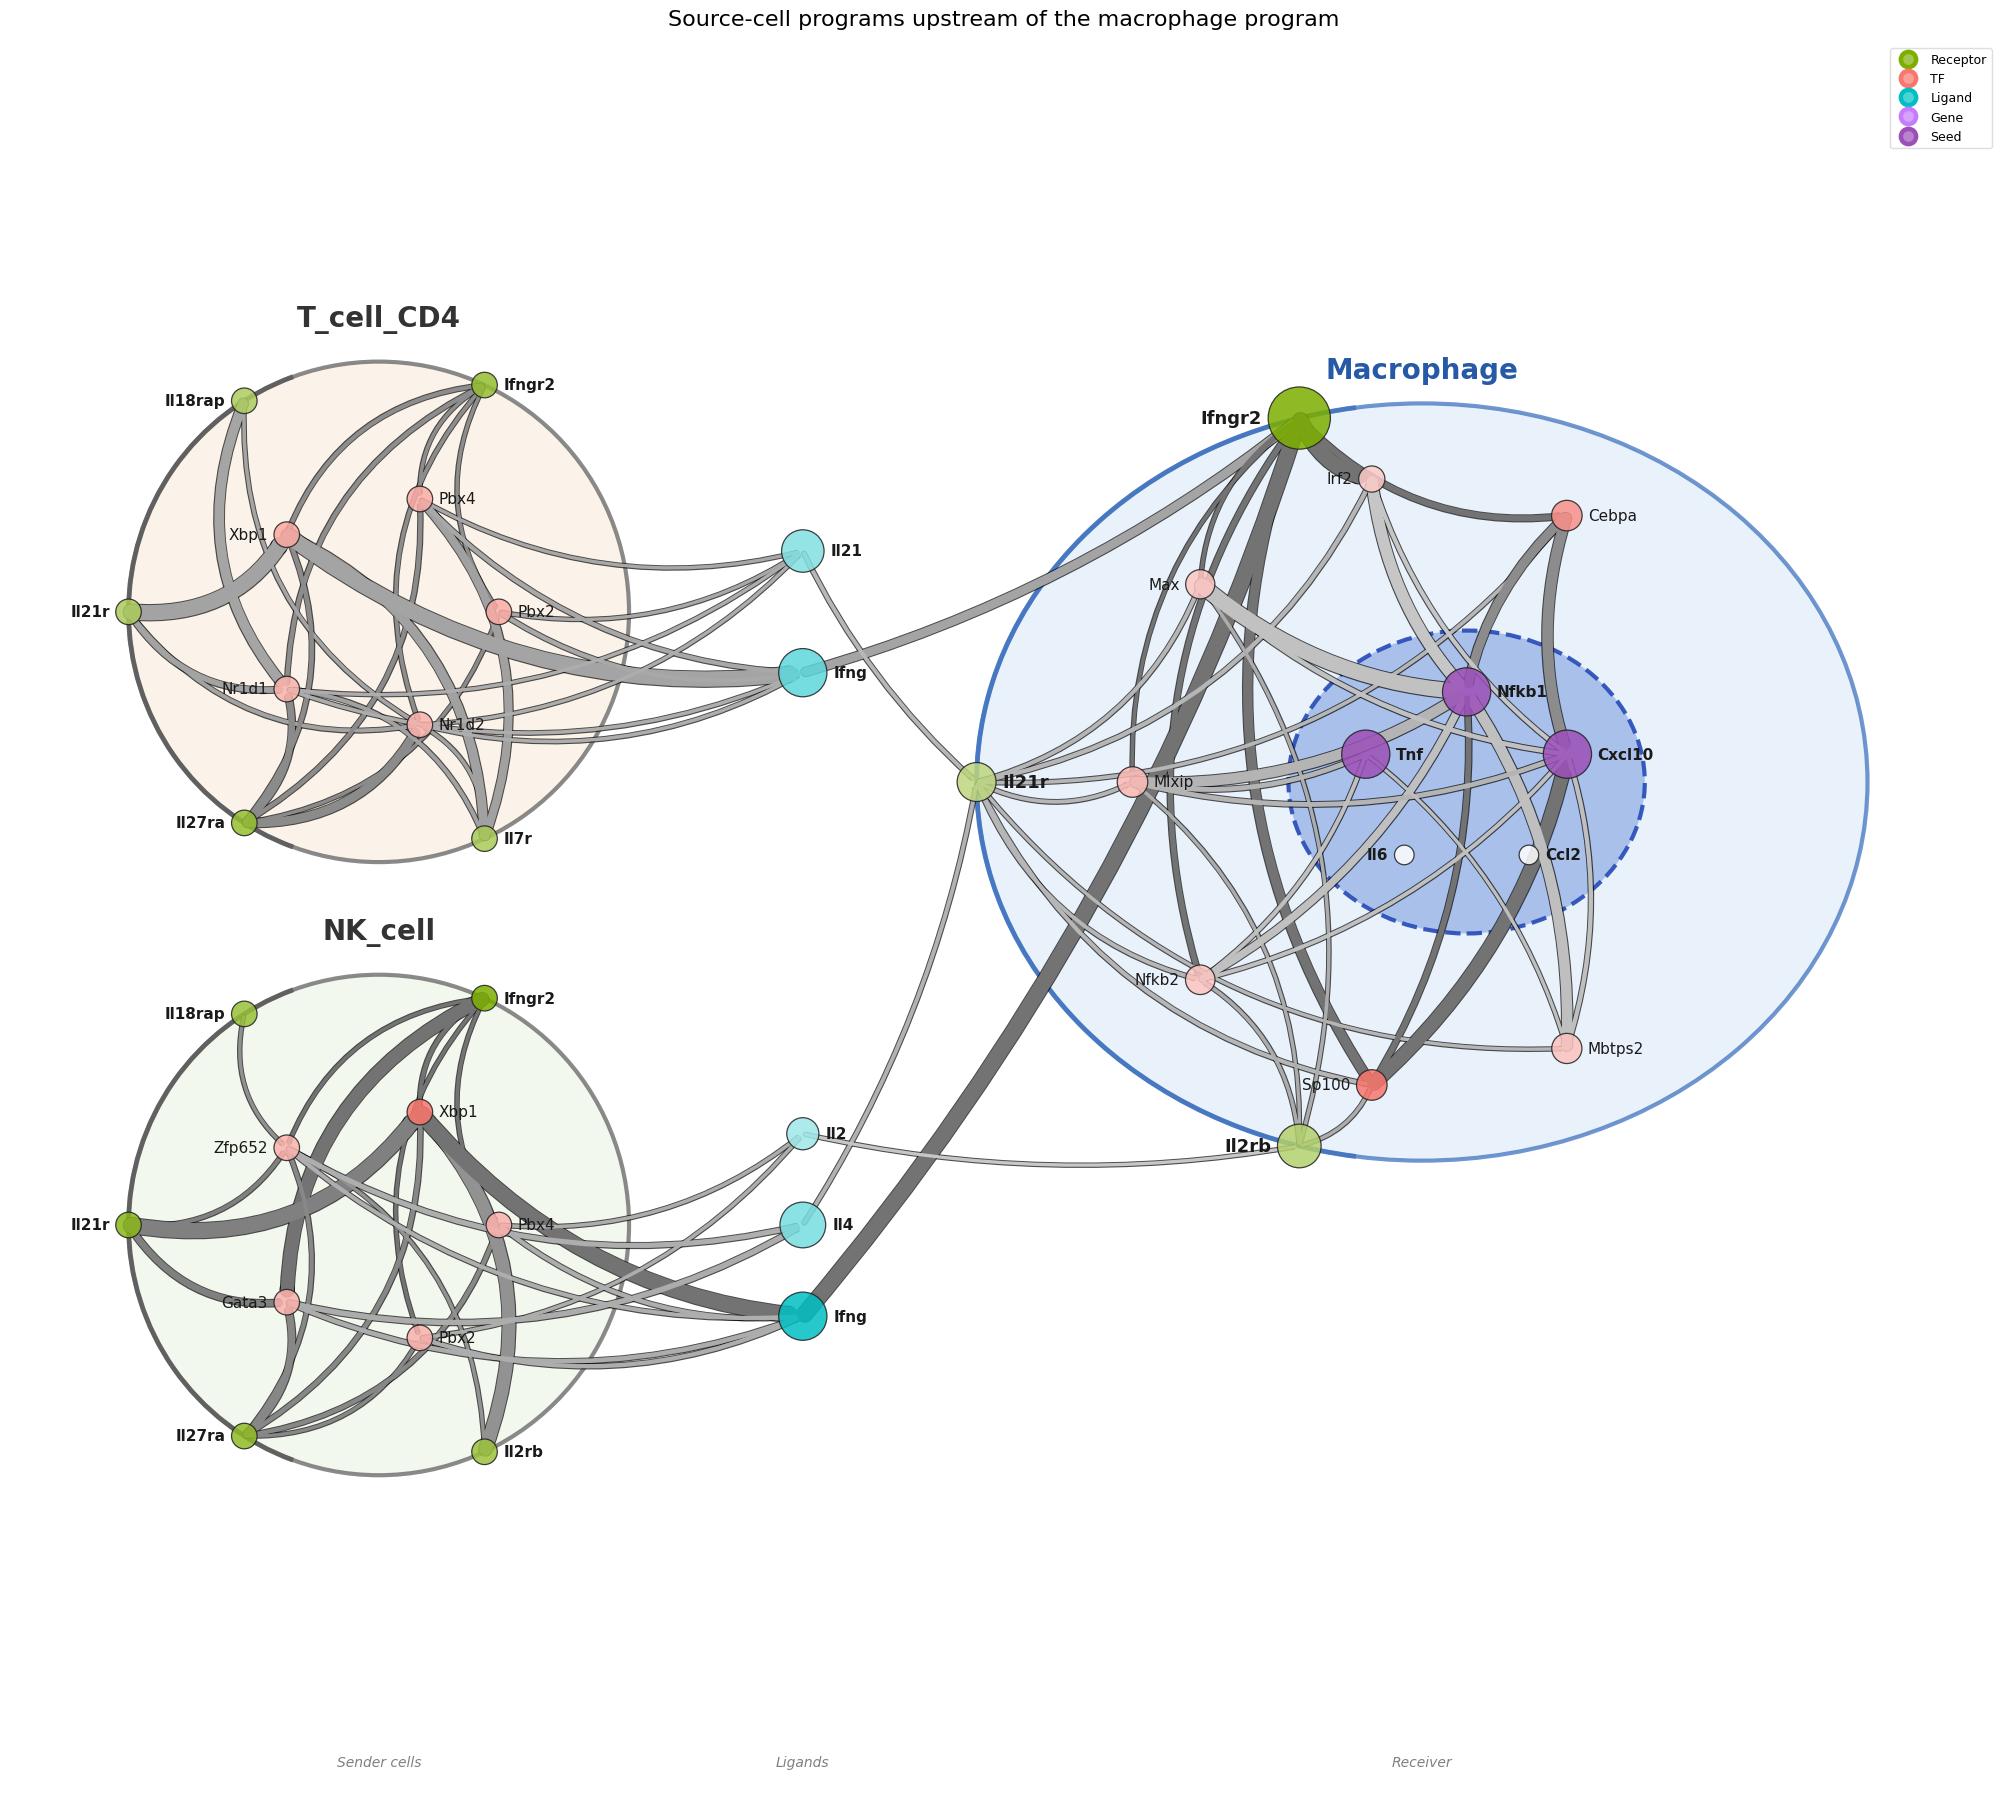

{'upstream_r_tf': 35,
 'upstream_tf_lig': 18,
 'lig_rec': 5,
 'rec_tf': 17,
 'tf_gene': 17}

In [90]:
fig, ax, complete_edges = cascade_plot(
    multicell, results,
    flow="upstream",
    title="Source-cell programs upstream of the macrophage program",
    return_edges=True,
    **common_plot_kwargs,
)
{k: len(v) for k, v in complete_edges.items()}

## 3. Inspect and save the selected cascade

`return_edges=True` exposes the exact edge tables used by the figure. Inspecting them is important when a layer is unexpectedly empty or a cell type disappears: cascade plots retain only complete paths connecting the selected layers.

In [91]:
edge_count_summary = pd.DataFrame({
    "intracellular": {k: len(v) for k, v in intracellular_edges.items()},
    "from_ligands": {k: len(v) for k, v in ligand_edges.items()},
    "complete": {k: len(v) for k, v in complete_edges.items()},
}).T
edge_count_summary

,upstream_r_tf,upstream_tf_lig,lig_rec,rec_tf,tf_gene
intracellular,0,0,0,17,17
from_ligands,0,0,5,17,17
complete,35,18,5,17,17


Saved: macrophage_cascade.png


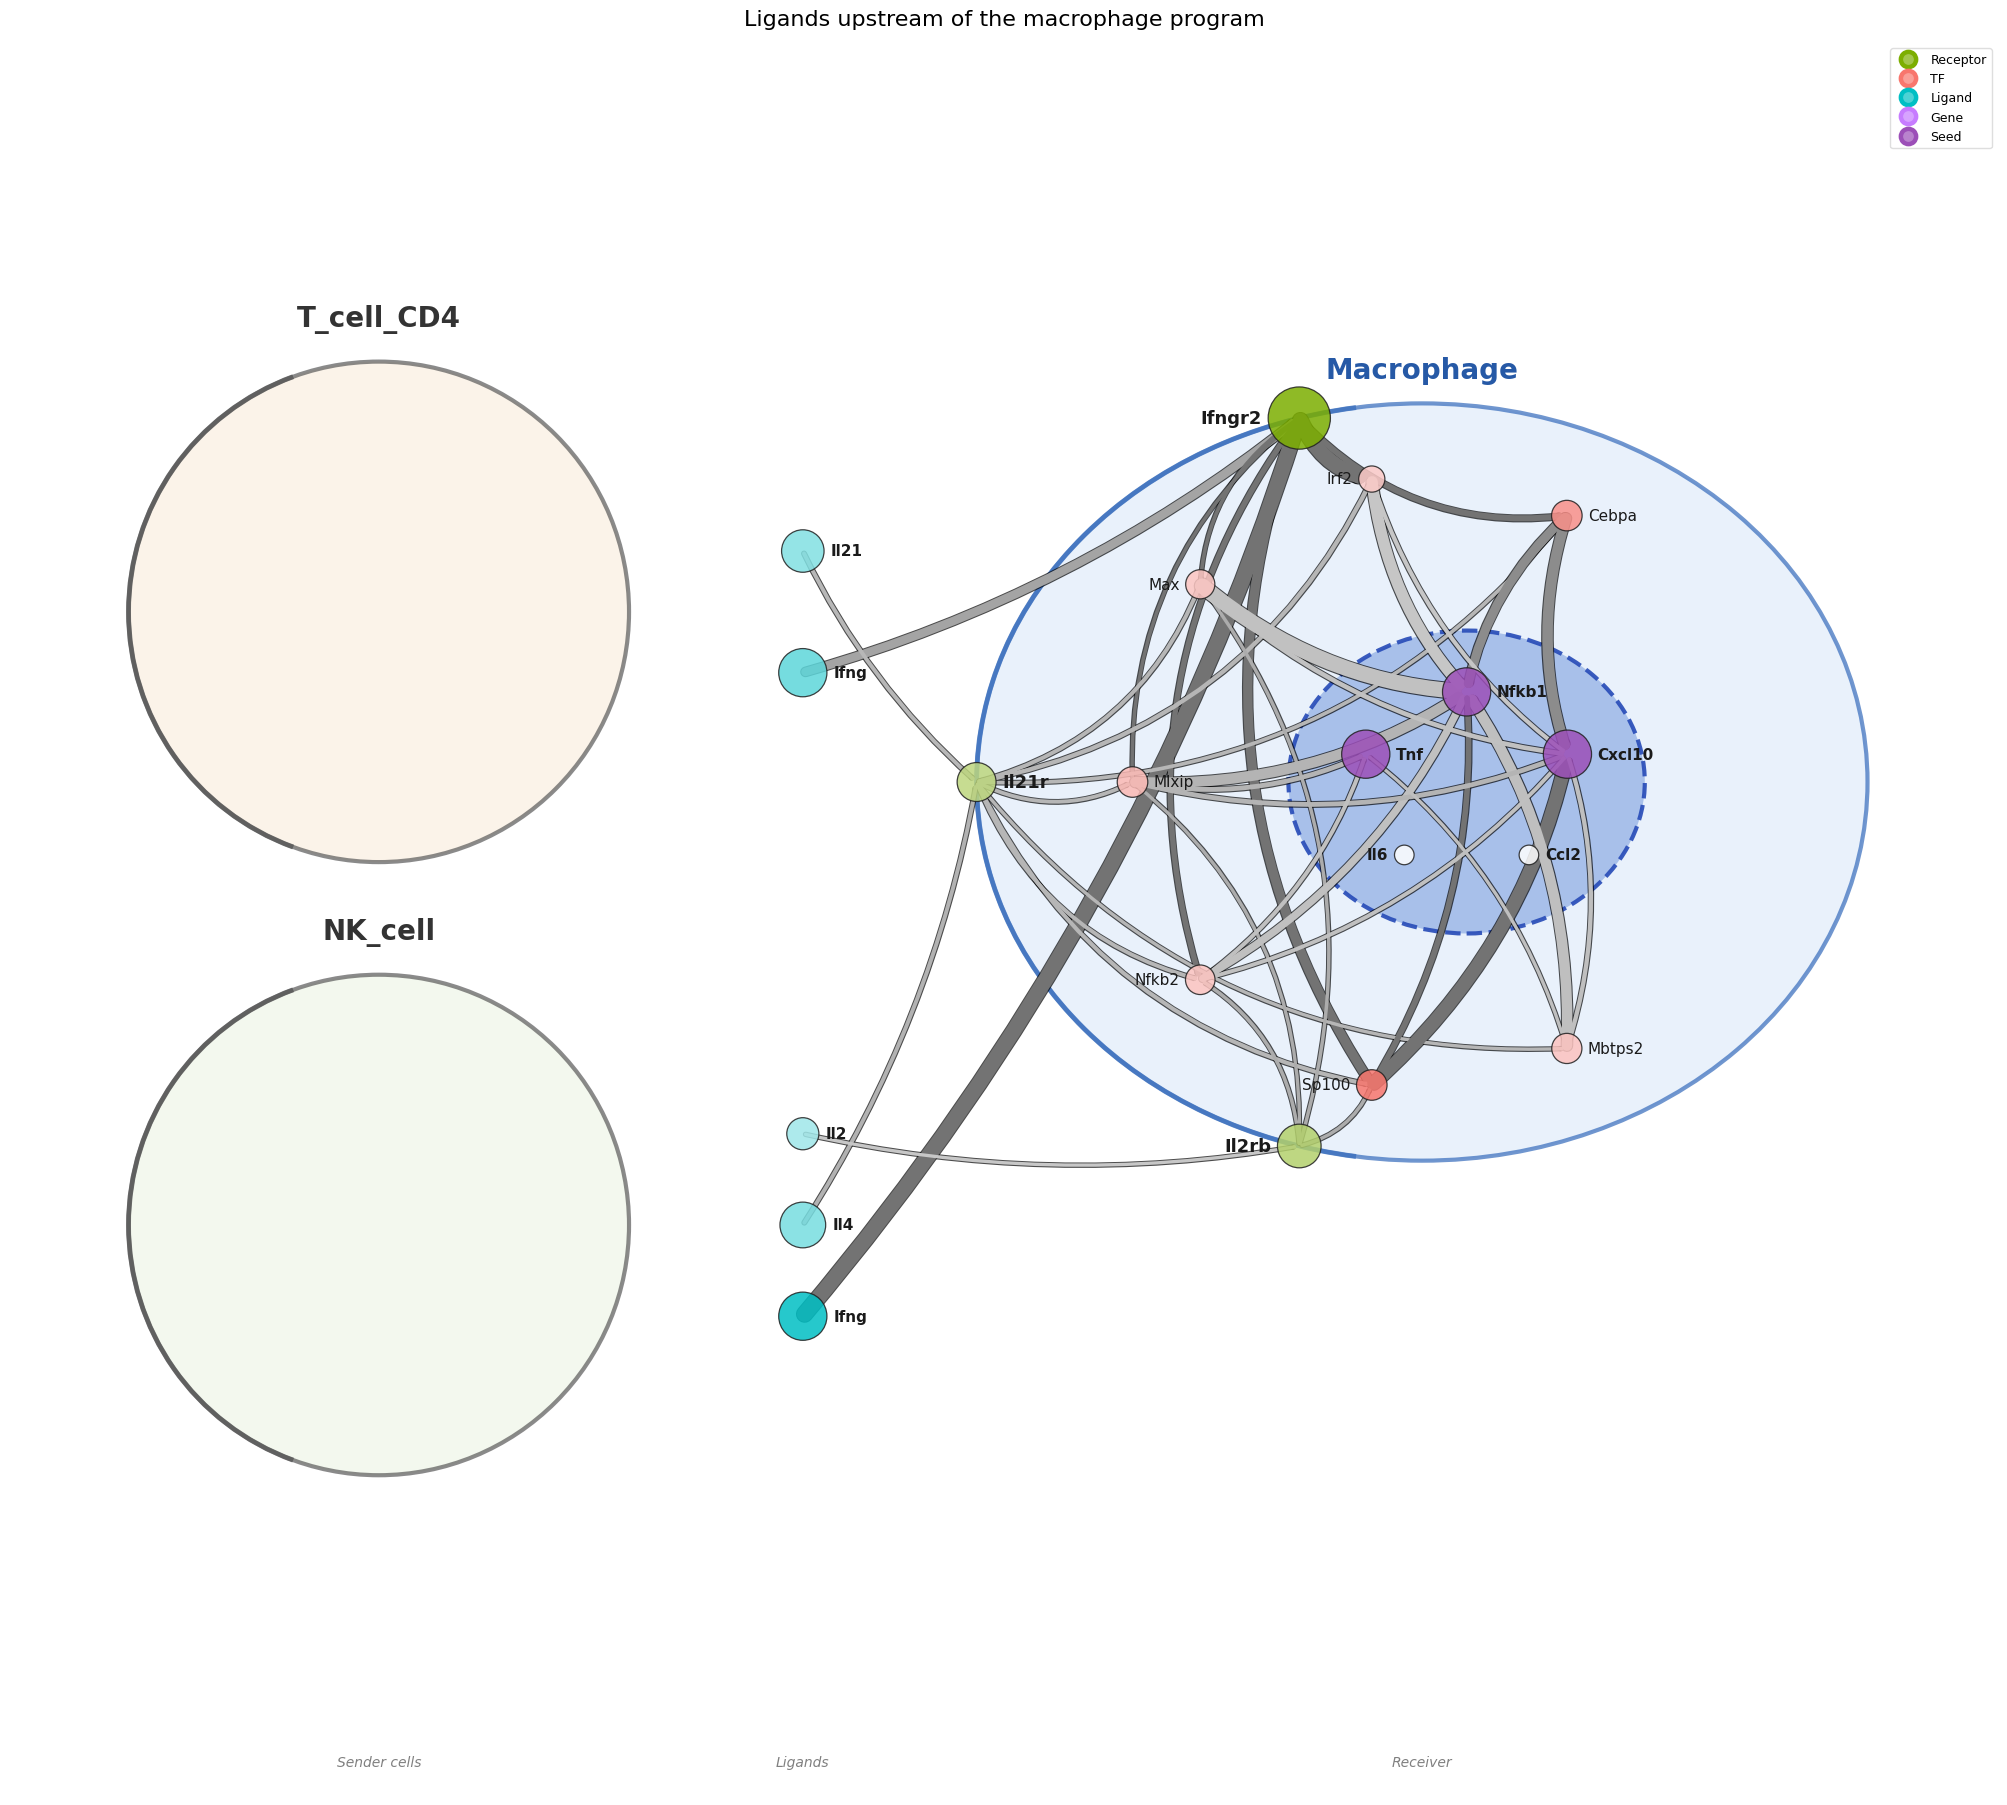

(<Figure size 2516.45x1815.84 with 1 Axes>,
 <Axes: title={'center': 'Ligands upstream of the macrophage program'}>)

In [92]:
cascade_plot(
    multicell, results,
    flow="upstream",
    start_layer="ligands", stop_layer="genes",
    title="Ligands upstream of the macrophage program",
    save_path="macrophage_cascade.png",
    **common_plot_kwargs,
)

## 4. Compare two conditions

```{note}
**In short**

Run ReCoN once per condition, then color the cascade using the difference between their ReCoN scores.
```

A standard cascade displays one ReCoN result. A contrast cascade displays the differences between two conditions. To create two conditions from this single tutorial dataset, we modify two inputs: the cell-cell communication weights and the seed weights. In condition B, we permute the weights of 35% of the communication edges. We also give alternating seed genes a higher weight in each condition. The last seed receives the same intermediate weight in both conditions, so the total seed weight remains equal. This is a simulated example for learning the function, not a biological comparison. In a real analysis, use communication networks and seed weights obtained separately for each condition—for example, the healthy and fibrotic niches from tutorial 6.

Both conditions must use the same node names and types of network layers so that ReCoN can compare their scores along the same paths.

### Define a local model constructor

```{note}
**What this represents**

This helper avoids writing the same `Multicell` constructor twice. It does not define either condition: the communication network and seed weights are provided in the following steps.
```

In [93]:
def build_context_model(context_ccc, context_seeds):
    model = recon.explore.Multicell(
        celltypes={ct: recon.explore.Celltype(
            celltype_name=ct, grn_graph=grn,
            receptor_grn_bipartite=receptor_genes,
            receptor_graph_directed=False, receptor_graph_weighted=False,
            grn_graph_directed=False, grn_graph_weighted=True,
            receptor_grn_bipartite_graph_directed=False,
            receptor_grn_bipartite_graph_weighted=True, seeds=[],
        ) for ct in celltypes},
        cell_communication_graph=context_ccc,
        cell_communication_graph_directed=False,
        cell_communication_graph_weighted=True,
        bipartite_grn_cell_communication_directed=False,
        bipartite_grn_cell_communication_weighted=False,
        bipartite_cell_communication_receptor_directed=False,
        bipartite_cell_communication_receptor_weighted=False,
        seeds=context_seeds,
    )
    model.lamb = recon.explore.set_lambda(
        model, direction="upstream", strategy="intercell"
    )
    return model

### Create a communication network for each condition

```{note}
**What this represents**

In a real comparison, the two communication networks would be inferred separately from different samples, conditions, or spatial niches. Here we only have one dataset, so we simulate a second network by permuting the weights of 35% of its CCC edges. The ligands, receptors, and communicating cell types remain unchanged; only the interaction weights differ.
```

In [94]:
context_ccc_a = ccc[
    ccc["celltype_source"].isin(celltypes)
    & ccc["celltype_target"].isin(celltypes)
].copy()
context_ccc_b = context_ccc_a.copy()

perturbed_edges = context_ccc_b.sample(frac=0.35, random_state=7).index
permuted_weights = context_ccc_b.loc[perturbed_edges, "weight"].to_numpy(copy=True)
np.random.default_rng(7).shuffle(permuted_weights)
context_ccc_b.loc[perturbed_edges, "weight"] = permuted_weights

### Create weighted seeds for each condition

```{note}
**What this represents**

A seed weight tells ReCoN how much importance to give each starting gene. For example, these weights can be based on gene expression measured by scRNA-seq in each condition. To simulate it here, we are giving different weights to the same set of studied genes used as seed. These values are only used to simulate the tutorial example; weights in a real comparison should be calculated in the same way for every condition, for example taking their scRNA-seq expression. _As ReCoN directly normalize seed weights, you can literally just give single-cell RNA-seq counts._
```

In [95]:
seed_nodes = [f"{gene}::{focal_celltype}" for gene in seed_genes]
seed_weights_a = [1.0, 0.2, 1.0, 0.2, 0.6]
seed_weights_b = [0.2, 1.0, 0.2, 1.0, 0.6]
seeds_a = dict(zip(seed_nodes, seed_weights_a))
seeds_b = dict(zip(seed_nodes, seed_weights_b))
pd.DataFrame({"context A": seeds_a, "context B": seeds_b})

,context A,context B
Nfkb1::Macrophage,1.0,0.2
Tnf::Macrophage,0.2,1.0
Il6::Macrophage,1.0,0.2
Ccl2::Macrophage,0.2,1.0
Cxcl10::Macrophage,0.6,0.6


### Build and run one model per context

```{note}
**What this represents**

Both models use the same cell types, GRN, receptor links, RWR direction, and restart probability. Only the communication weights and seed weights differ.
```

In [96]:
multicell_a = build_context_model(context_ccc_a, seeds_a)
multicell_b = build_context_model(context_ccc_b, seeds_b)

/pasteur/helix/projects/ml4ig_hot/Users/rtrimbou/ReCoN/src/recon/explore/recon.py:132: UserWarning: 
                No receptor_graph provided,
                an empty receptor graph will be created.
                
/pasteur/helix/projects/ml4ig_hot/Users/rtrimbou/ReCoN/src/recon/explore/recon.py:474: UserWarning: The celltypes dictionary was converted to a list of Celltype objects.
The keys of the dictionary will be the celltype names.
/pasteur/helix/projects/ml4ig_hot/Users/rtrimbou/ReCoN/src/recon/explore/recon.py:132: UserWarning: 
                No receptor_graph provided,
                an empty receptor graph will be created.
                
/pasteur/helix/projects/ml4ig_hot/Users/rtrimbou/ReCoN/src/recon/explore/recon.py:474: UserWarning: The celltypes dictionary was converted to a list of Celltype objects.
The keys of the dictionary will be the celltype names.


In [97]:
results_a = multicell_a.explore(restart_proba=0.6)
results_b = multicell_b.explore(restart_proba=0.6)

Seeds are provided as a dictionary with weights per seed.
Creating a multixrank object with seeds as a dictionary.
cell_communication
receptor
gene
receptor
gene
receptor
gene
receptor
gene
receptor
gene
receptor
gene
Identifying produced ligands in response to the perturbation.
Seeds are provided as a dictionary with weights per seed.
Creating a multixrank object with seeds as a dictionary.
cell_communication
receptor
gene
receptor
gene
receptor
gene
receptor
gene
receptor
gene
receptor
gene
Identifying produced ligands in response to the perturbation.


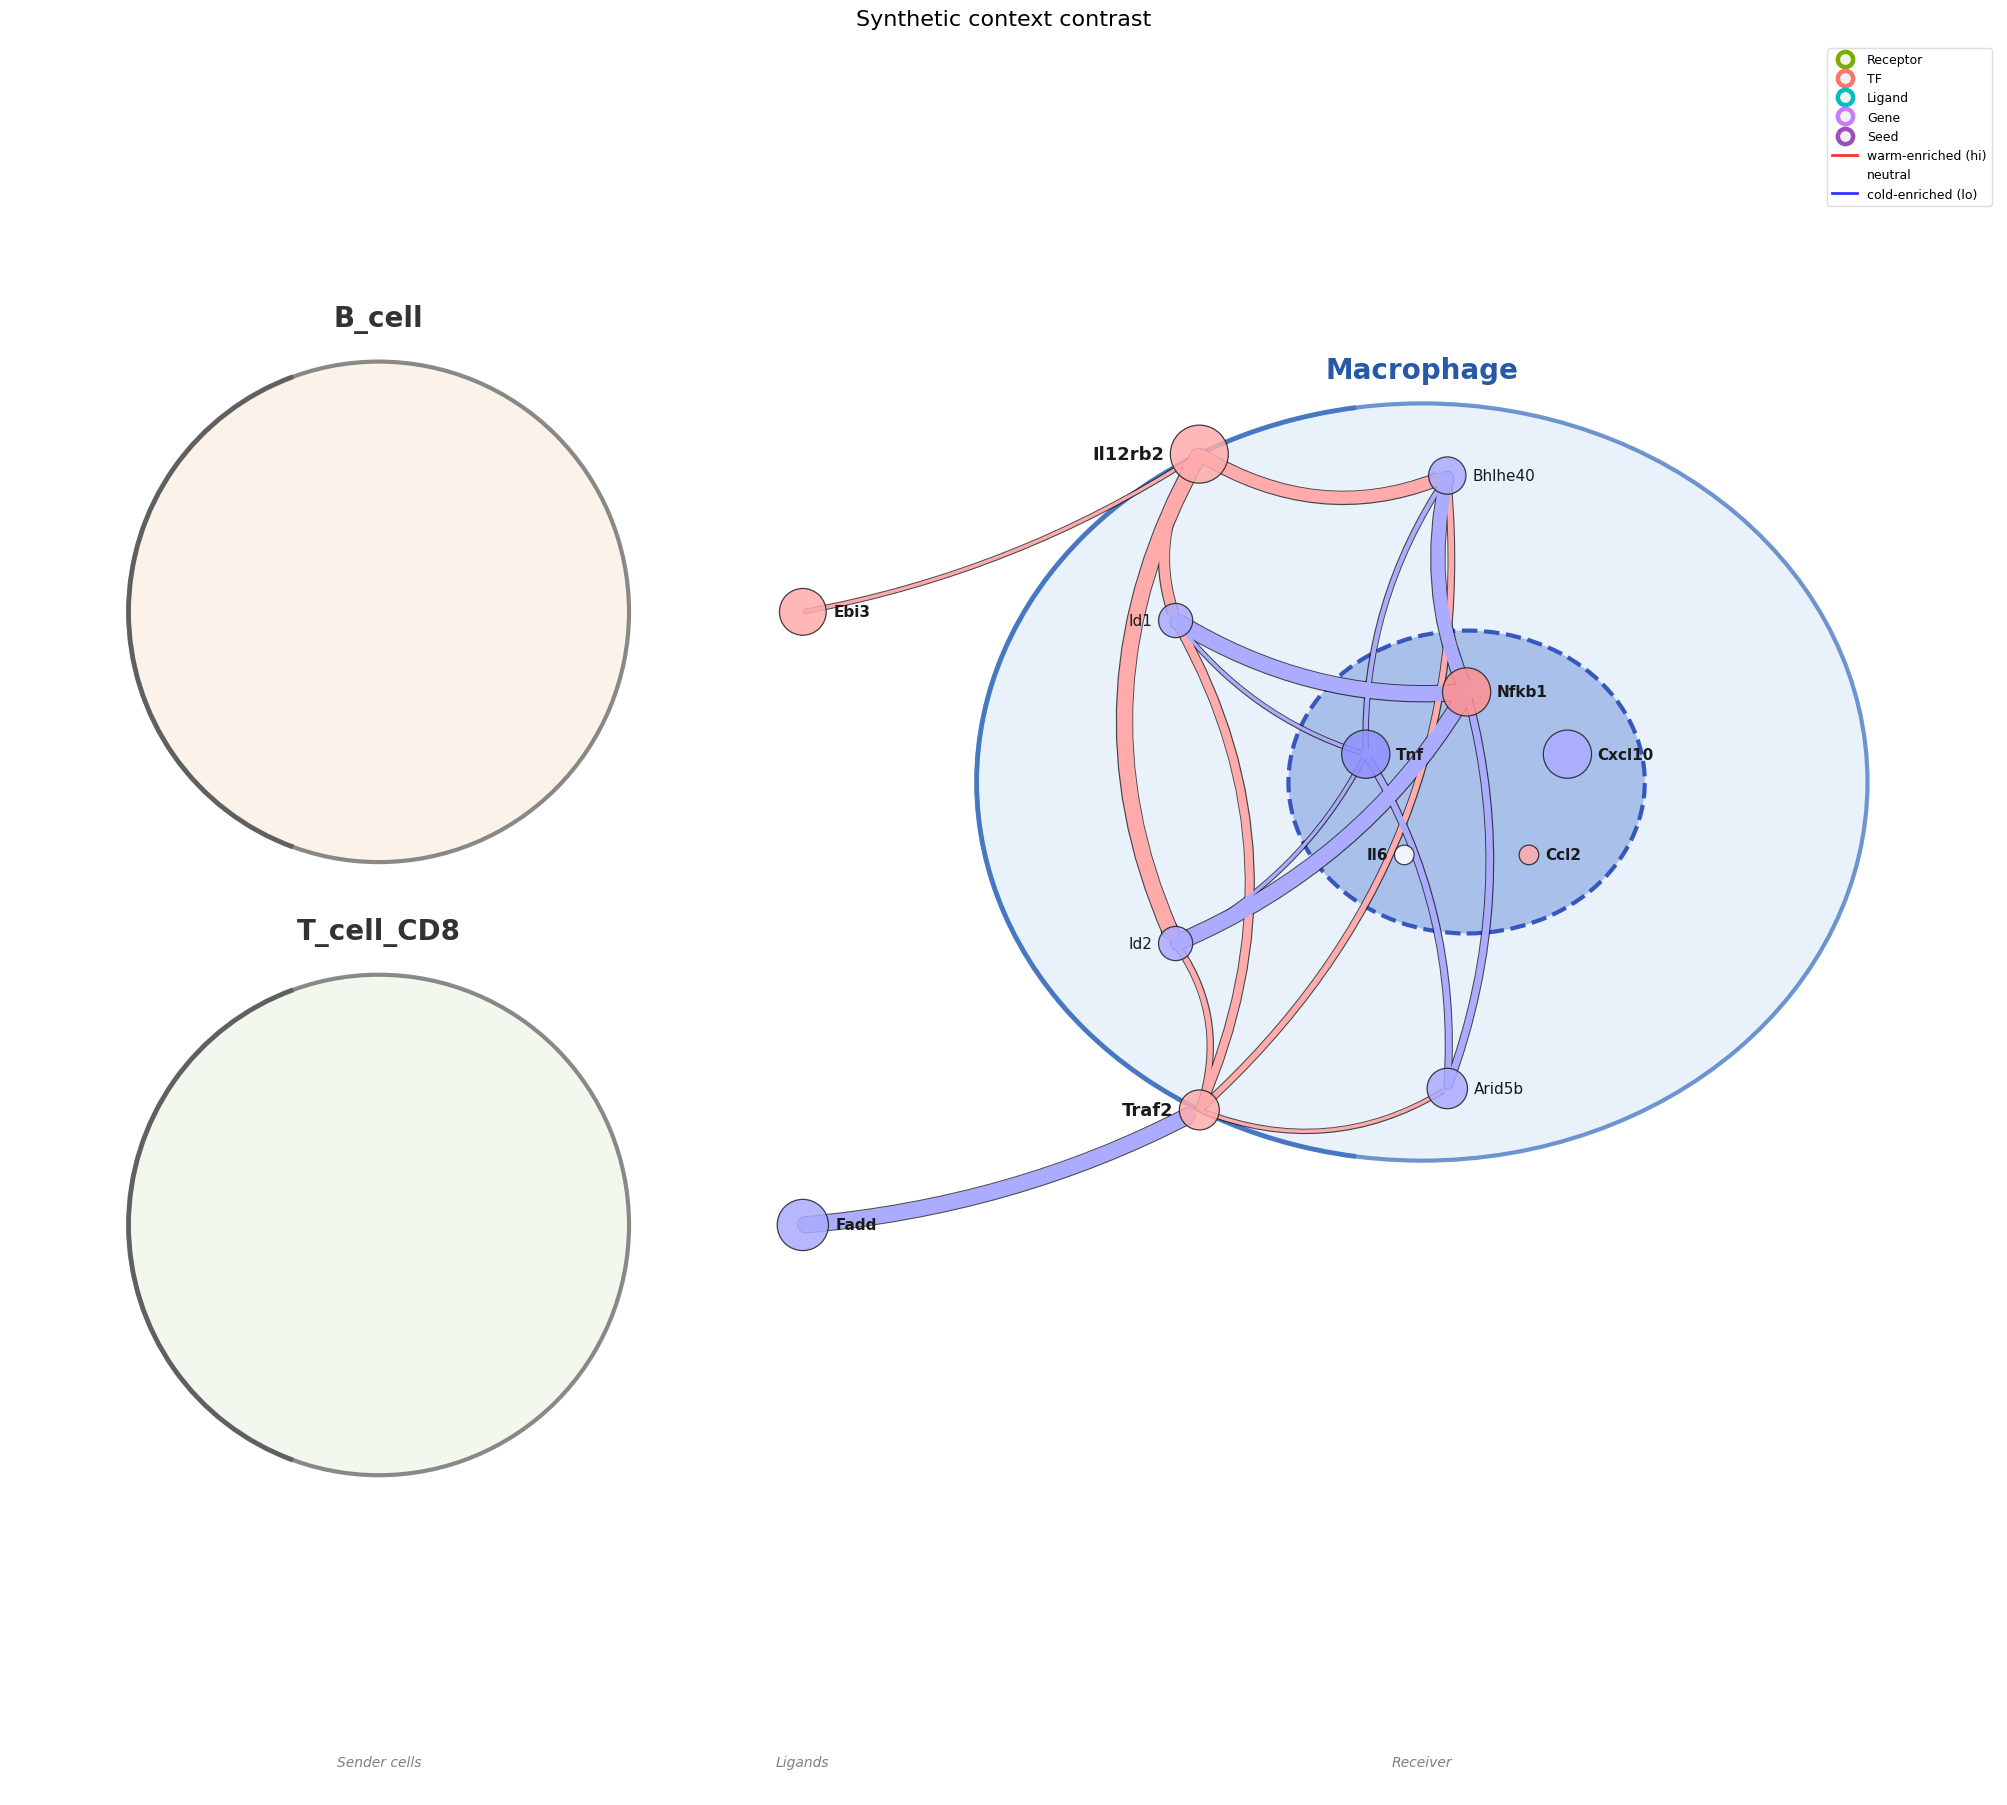

{'upstream_r_tf': 0,
 'upstream_tf_lig': 0,
 'lig_rec': 2,
 'rec_tf': 7,
 'tf_gene': 8}

In [99]:
fig, ax, contrast_edges = contrast_cascade_plot(
    {"context A": multicell_a, "context B": multicell_b},
    results_a, results_b,
    flow="upstream",
    start_layer="ligands",
    stop_layer="genes",
    title="Synthetic context contrast",
    normalize_receiver_scores=False,
    delta_min_quantile=0.0,
    delta_min_color_fraction=0.25,
    return_edges=True,
    **common_plot_kwargs,
)
{k: len(v) for k, v in contrast_edges.items()}

Blue nodes have a higher absolute ReCoN score in condition B, red nodes have a higher score in condition A, and near-white nodes change little. `normalize_receiver_scores=False` displays the original score differences. `delta_min_quantile=0.0` keeps all selected paths in this small example; increasing it keeps only paths with larger differences.

### Display more ligands, receptors, and TFs

The first plot displays only a small number of connected ligands and receptors. The `top_*_n` parameters control how many highly ranked nodes ReCoN considers when building the paths. Here we increase these values to display more ligands, receptors, and TFs. Larger values can make the plot denser and take longer to compute.

We also set `normalize_receiver_scores=True`. ReCoN rescales the score differences separately for macrophage receptors, TFs, and genes, using the largest absolute difference in each layer. This makes colors easier to see when one layer has much smaller scores than another. Red and blue keep the same meaning as above, but their intensity is relative to the strongest difference in that layer. Use `False` when you need to compare the original difference sizes across layers.

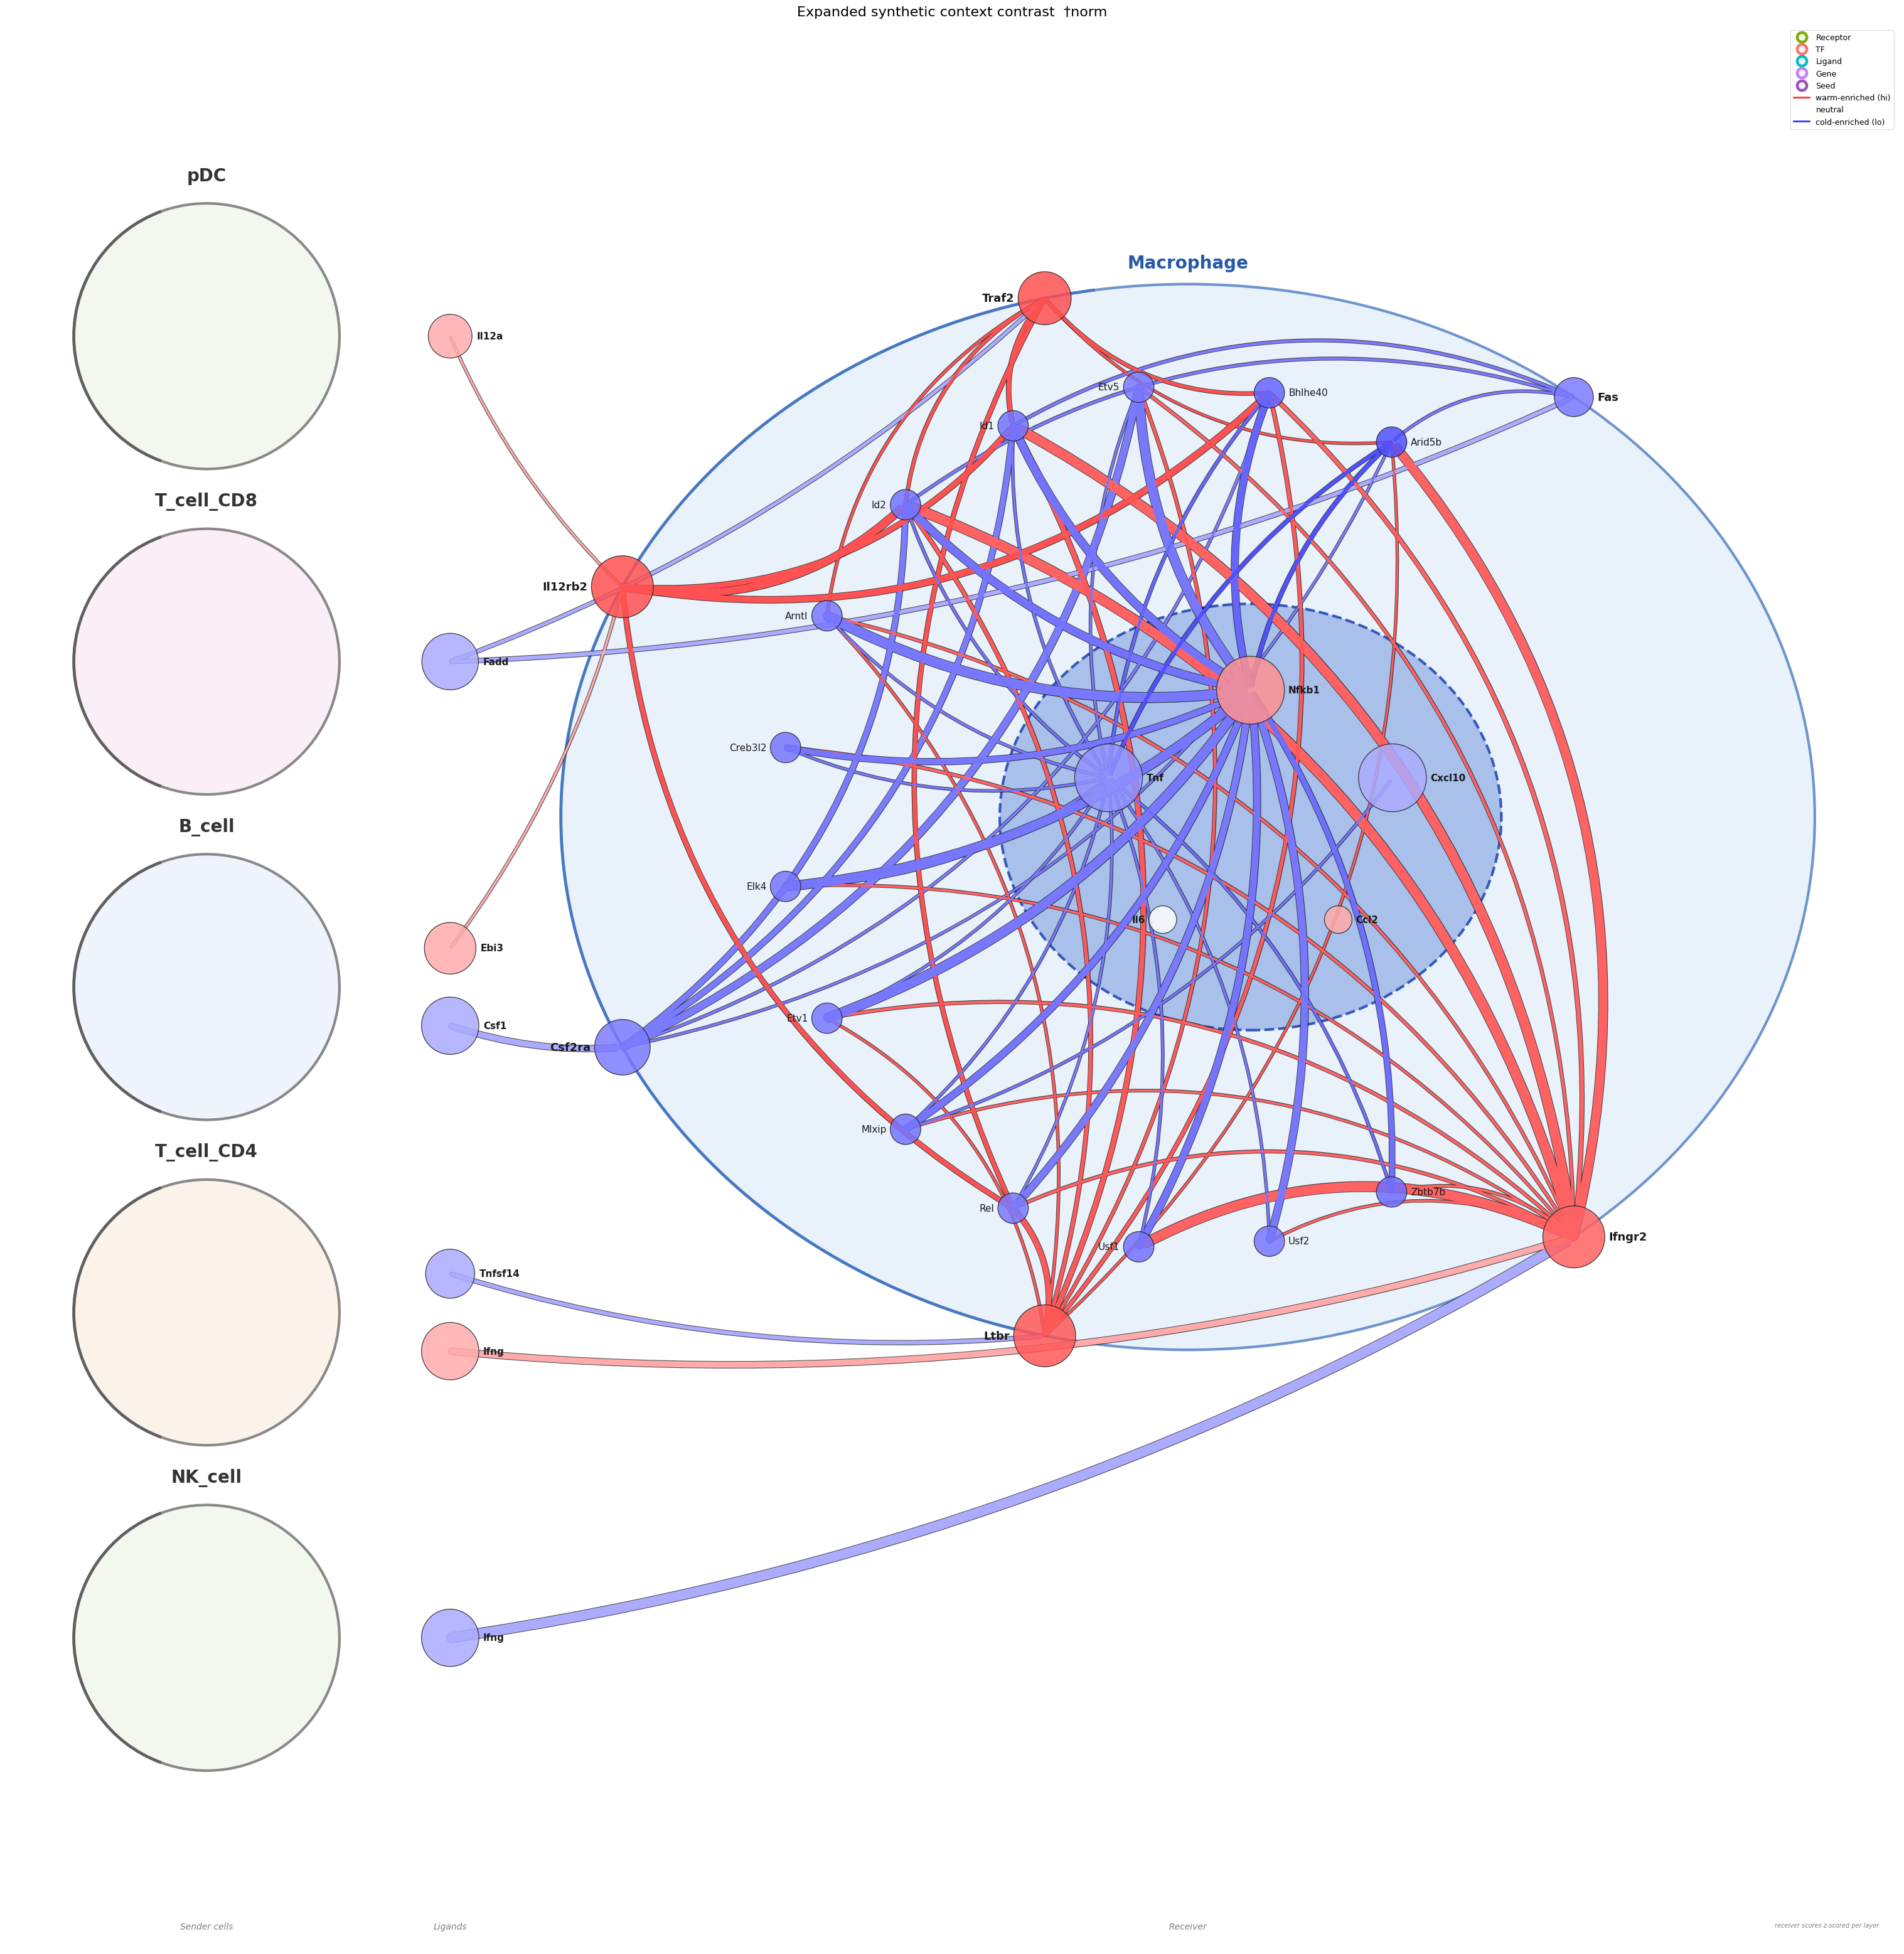

{'upstream_r_tf': 0,
 'upstream_tf_lig': 0,
 'lig_rec': 8,
 'rec_tf': 40,
 'tf_gene': 29}

In [100]:
expanded_plot_kwargs = {
    **common_plot_kwargs,
    "top_ligand_n": 20,
    "top_receptor_n": 20,
    "top_tf_n": 15,
}

fig, ax, expanded_contrast_edges = contrast_cascade_plot(
    {"context A": multicell_a, "context B": multicell_b},
    results_a, results_b,
    flow="upstream",
    start_layer="ligands",
    stop_layer="genes",
    title="Expanded synthetic context contrast",
    normalize_receiver_scores=True,
    delta_min_quantile=0.0,
    delta_min_color_fraction=0.25,
    return_edges=True,
    **expanded_plot_kwargs,
)
{k: len(v) for k, v in expanded_contrast_edges.items()}

### Too much of a good thing?

For comparison, the deliberately excessive settings below request 85 TFs. The resulting hairball is valid—but interpretation becomes an endurance sport. It is a useful reminder that displaying more paths does not always make the biology clearer.

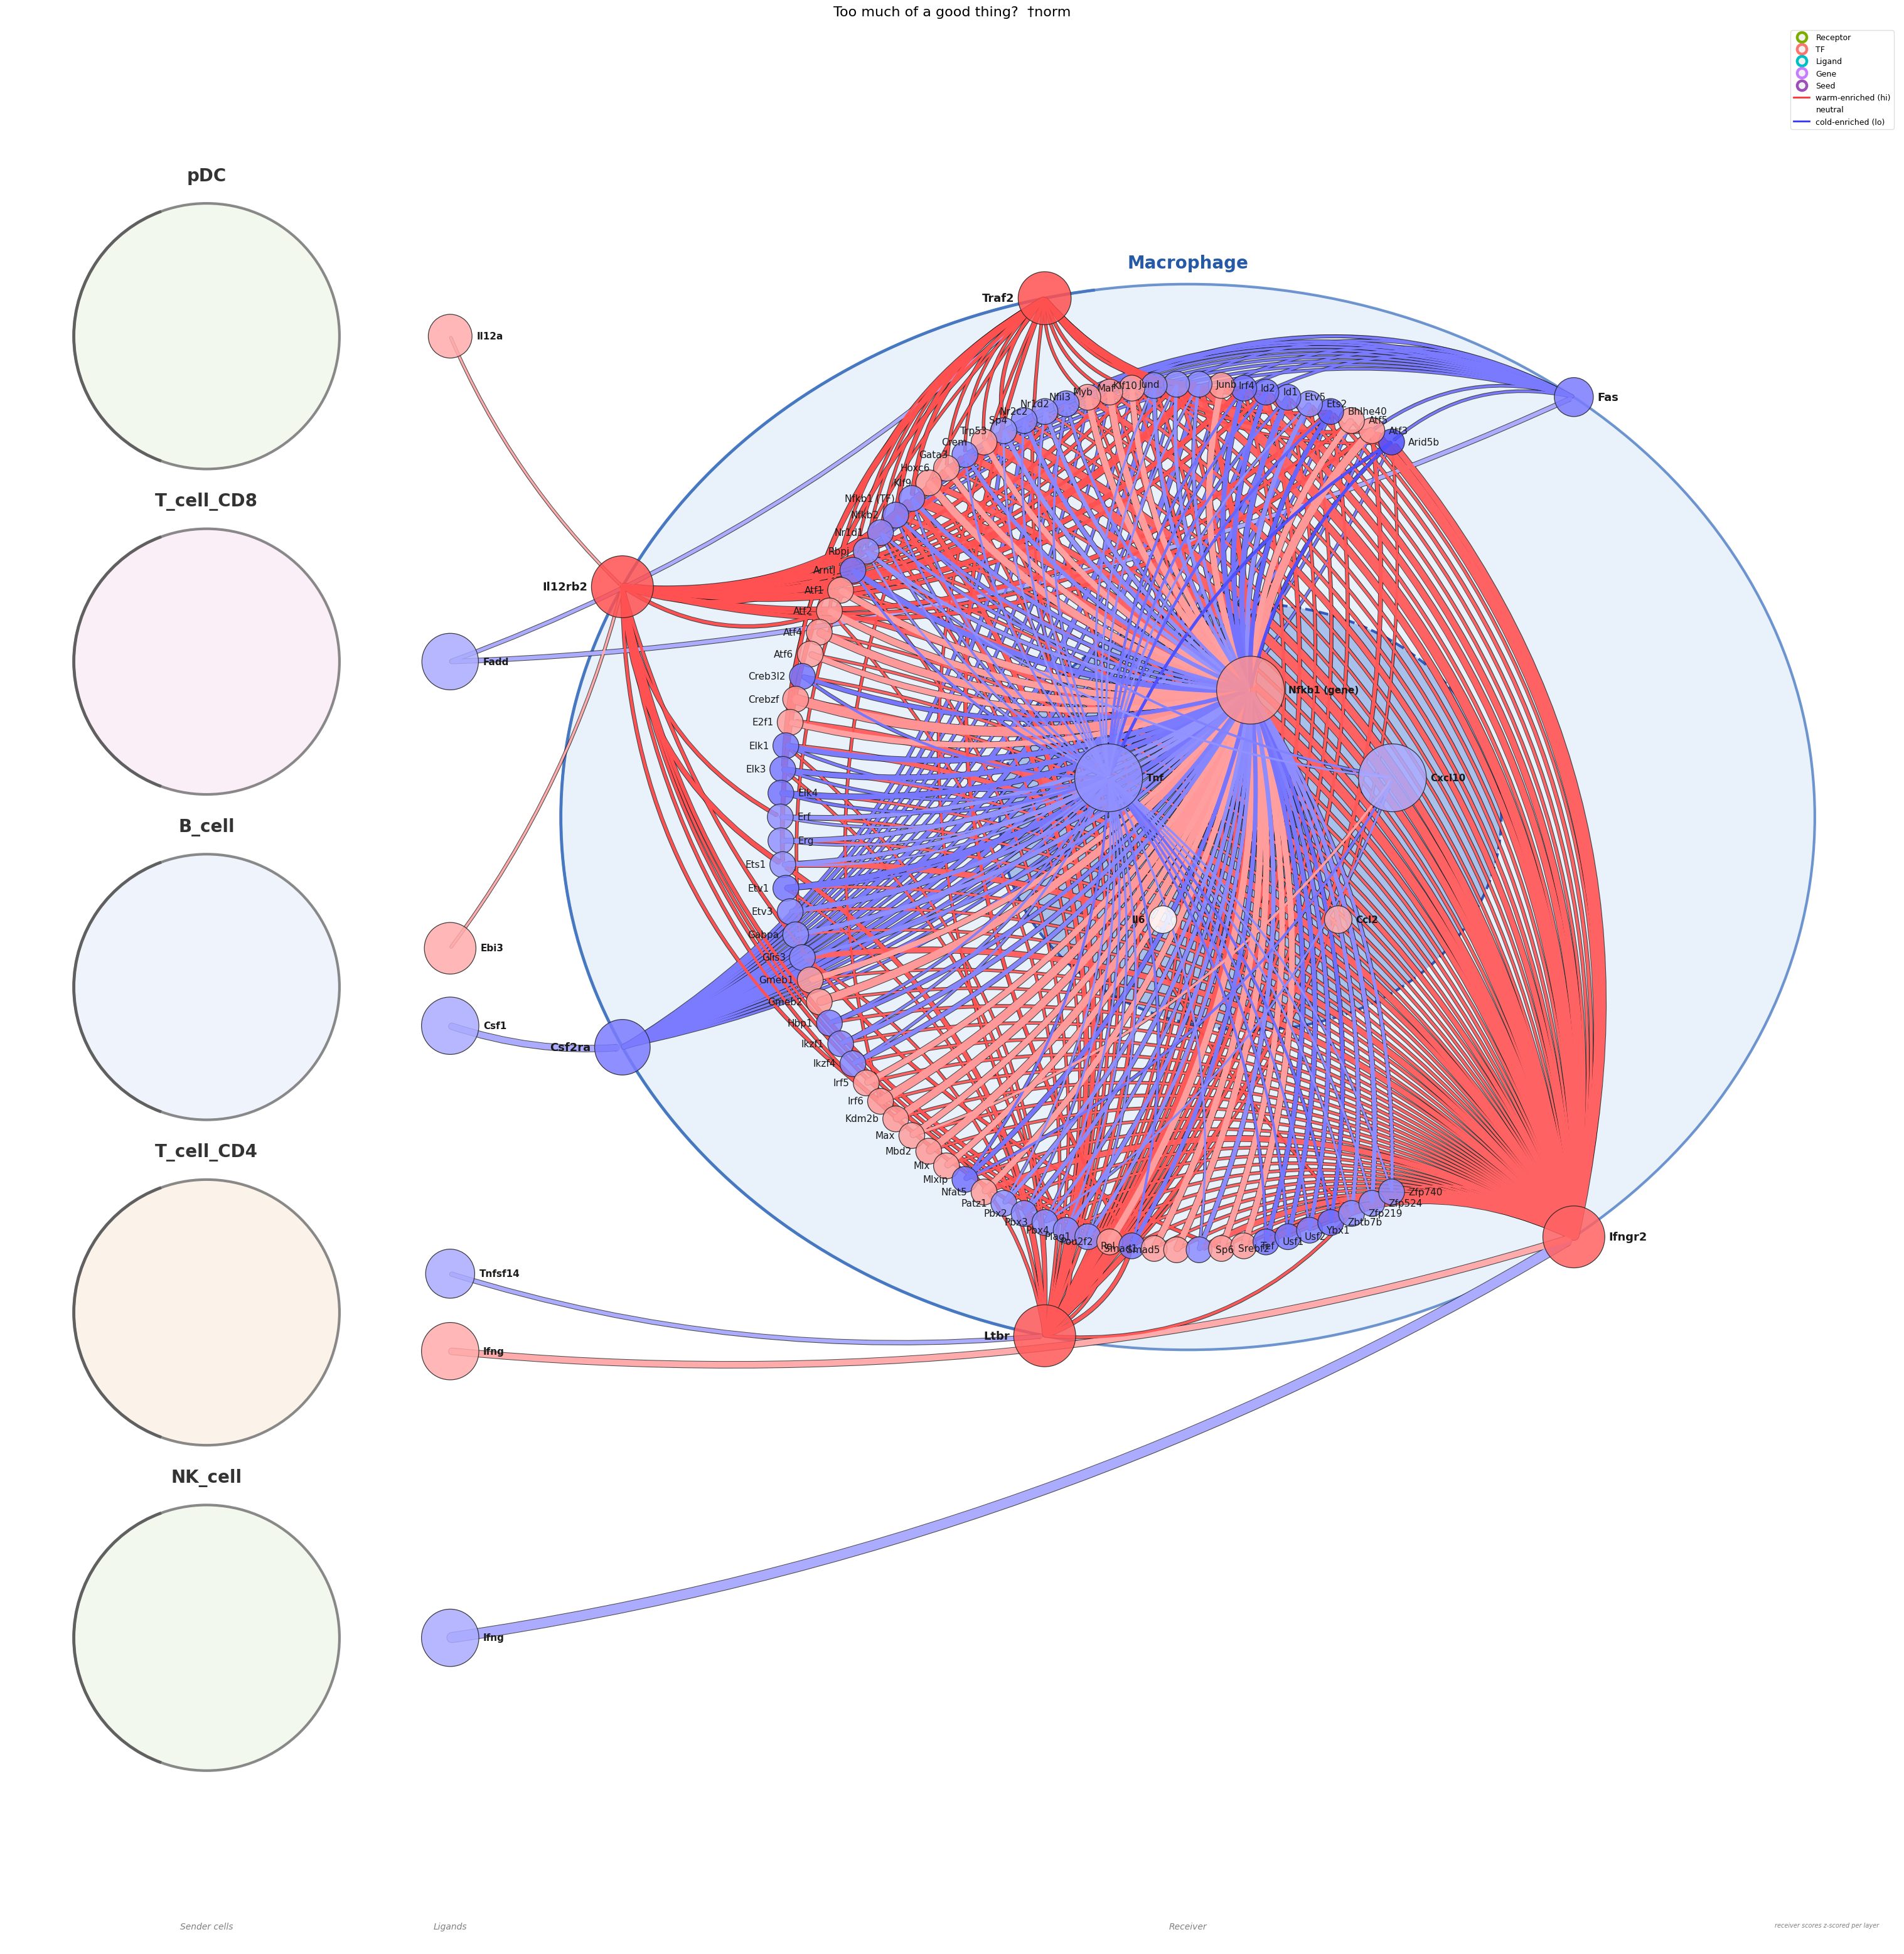

{'upstream_r_tf': 0,
 'upstream_tf_lig': 0,
 'lig_rec': 8,
 'rec_tf': 200,
 'tf_gene': 130}

In [101]:
too_much_plot_kwargs = {
    **common_plot_kwargs,
    "top_ligand_n": 20,
    "top_receptor_n": 20,
    "top_tf_n": 85,
}

fig, ax, too_much_contrast_edges = contrast_cascade_plot(
    {"context A": multicell_a, "context B": multicell_b},
    results_a, results_b,
    flow="upstream",
    start_layer="ligands",
    stop_layer="genes",
    title="Too much of a good thing?",
    normalize_receiver_scores=True,
    delta_min_quantile=0.0,
    delta_min_color_fraction=0.25,
    return_edges=True,
    **too_much_plot_kwargs,
)
{k: len(v) for k, v in too_much_contrast_edges.items()}

**How to tune the contrast**

- Increase `top_ligand_n`, `top_receptor_n`, or `top_tf_n` when too few nodes of that type are displayed. ReCoN keeps only connected paths, so requesting 20 nodes does not guarantee that 20 will appear.
- Increase `before_top_n` only for the complete cascade. It controls the receptors and TFs in the cells producing the ligands.
- Increase `delta_min_quantile` to remove edges with small score differences and simplify a dense figure. Keep it near zero when first checking which paths are available.
- Increase `delta_min_color_fraction` to make small non-zero differences easier to see. This affects color visibility, not edge selection or the underlying score.
- Set `normalize_receiver_scores=False` to compare the original score differences across layers. Set it to `True` when macrophage receptors, TFs, and genes should each use their own color range.

```{warning}
A cascade plot shows paths supported by the ReCoN scores and input networks. It does not prove that every displayed interaction occurs in the sample. Only paths present in the GRN, receptor links, and CCC network can appear. Validate important interactions using expression data and experiments.
```

```{tip}
If a layer is empty, use `verbose=True`, inspect the returned edge tables, or increase `top_ligand_n`, `top_receptor_n`, `top_tf_n`, and `before_top_n`.
```